# Valuación de opciones europeas y asiáticas mediante simulación Monte Carlo

**Diego Dueñas Martín**  
**Expediente:** 751426  
**Fecha:** 15 de septiembre de 2026

## Simulación de trayectorias con movimiento browniano geométrico

El precio del activo subyacente se modela bajo la dinámica neutral al riesgo del modelo de Black-Scholes, donde el logaritmo del precio sigue un movimiento browniano geométrico:

$$dS_t = rS_t\,dt + \sigma S_t\,dW_t$$

Discretizando esta ecuación con el esquema exacto (que trabaja directamente sobre $\ln S_t$ y evita sesgos de discretización), el precio en cada paso se obtiene como:

$$S_{t+\Delta t} = S_t \exp\left[\left(r - \tfrac{1}{2}\sigma^2\right)\Delta t + \sigma\sqrt{\Delta t}\,Z_t\right], \quad Z_t \sim N(0,1)$$

Con esta fórmula se generan 1,000 trayectorias diarias durante un año ($T=1$, 252 días hábiles), partiendo de un precio inicial $S_0=100$, tasa libre de riesgo $r=5\%$ y volatilidad $\sigma=20\%$. Al final también se calcula el intervalo de confianza del 95% de la distribución de precios en cada día, usando los percentiles 2.5 y 97.5 de las trayectorias simuladas.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Parámetros del modelo
S0 = 100
r = 0.05
vol = 0.2
T = 1
num_days = 252
num_trajectories = 1000
dt = T / num_days

# Inicialización de trayectorias
price_trajectories = np.zeros((num_days + 1, num_trajectories))
price_trajectories[0, :] = S0

# Simulación de Monte Carlo
for i in range(num_trajectories):
    Z = np.random.standard_normal(num_days)
    for t in range(1, num_days + 1):
        price_trajectories[t, i] = price_trajectories[t - 1, i] * np.exp(
            (r - 0.5 * vol**2) * dt + vol * np.sqrt(dt) * Z[t - 1]
        )

# Intervalo de confianza del 95%
lower_bound = np.percentile(price_trajectories, 2.5, axis=1)
upper_bound = np.percentile(price_trajectories, 97.5, axis=1)


## Revisión de una muestra de trayectorias

Antes de graficar todo el conjunto conviene revisar los números directamente. Se arma una tabla con el día, dos trayectorias de ejemplo y los límites del intervalo de confianza del 95%, mostrando las primeras y las últimas filas para confirmar que la simulación arranca en $S_0=100$ y que el intervalo se va abriendo conforme pasa el tiempo.

In [6]:
import pandas as pd

# Transponer price_trajectories para tener 50 filas (trayectorias) y 253 columnas (días)
transposed_trajectories = price_trajectories.T

# Crear un DataFrame para mostrar una parte de las trayectorias y los límites del CI
# Se toma una muestra para no imprimir una matriz demasiado grande
data_sample = pd.DataFrame({
    'Día': range(num_days + 1),
    'Trayectoria 1 ': price_trajectories[:, 0],
    'Trayectoria 2 ': price_trajectories[:, 1],
    'Límite Inferior CI (2.5%)': lower_bound,
    'Límite Superior CI (97.5%)': upper_bound
})

# Mostrar las primeras y últimas filas del DataFrame
display(data_sample.head())
display(data_sample.tail())

,Día,Trayectoria 1,Trayectoria 2,Límite Inferior CI (2.5%),Límite Superior CI (97.5%)
0,0,100.000000,100.000000,100.000000,100.000000
1,1,98.904501,97.113872,97.378893,102.332911
2,2,97.899411,95.488764,96.510881,103.481930
3,3,97.426521,94.400484,95.701847,103.415952
4,4,99.783106,95.199438,96.254302,104.520453


,Día,Trayectoria 1,Trayectoria 2,Límite Inferior CI (2.5%),Límite Superior CI (97.5%)
248,248,110.843927,77.009675,73.269480,139.469938
249,249,110.884923,76.650673,72.714251,139.516612
250,250,108.556303,76.543083,72.768324,138.906853
251,251,109.613089,75.766235,73.064783,141.052385
252,252,110.595305,76.483440,72.040273,140.086207


## Visualización del abanico de trayectorias

Se grafican las 1,000 trayectorias simuladas (en gris, con transparencia para distinguir la densidad), junto con la trayectoria promedio y la banda del intervalo de confianza del 95%. Esto permite ver de forma intuitiva cómo se dispersa el precio del activo conforme avanza el tiempo.

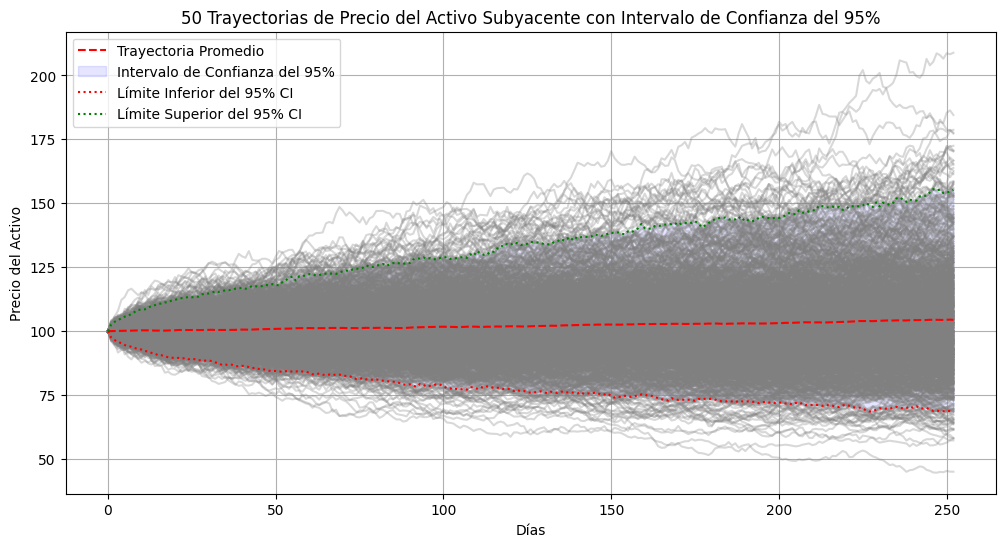

In [8]:
# Graficar las trayectorias
plt.figure(figsize=(12, 6))

# Plotear todas las trayectorias en gris
plt.plot(price_trajectories, color='grey', alpha=0.3)

# Calcular el promedio de las trayectorias
mean_trajectory = np.mean(price_trajectories, axis=1)

# Calcular el intervalo de confianza del 95% (percentiles 2.5 y 97.5)
lower_bound = np.percentile(price_trajectories, 2.5, axis=1)
upper_bound = np.percentile(price_trajectories, 97.5, axis=1)

# Plotear el promedio de las trayectorias
plt.plot(mean_trajectory, color='red', linestyle='--', label='Trayectoria Promedio')

# Rellenar el área del intervalo de confianza del 95%
plt.fill_between(range(num_days + 1), lower_bound, upper_bound, color='blue', alpha=0.1, label='Intervalo de Confianza del 95%')

# Plotear las líneas de los límites superior e inferior del intervalo de confianza
plt.plot(lower_bound, color='Red', linestyle=':', label='Límite Inferior del 95% CI')
plt.plot(upper_bound, color='Green', linestyle=':', label='Límite Superior del 95% CI')

plt.title('50 Trayectorias de Precio del Activo Subyacente con Intervalo de Confianza del 95%')
plt.xlabel('Días')
plt.ylabel('Precio del Activo')
plt.grid(True)
plt.legend()
plt.show()

## Precio promedio ponderado vs. precio final

Para preparar la valuación de la opción asiática se calcula $S_{testada}$, un promedio ponderado del precio a lo largo de cada trayectoria (dando más peso a los días más recientes), y se compara contra $S_{final}$, el precio de cierre de cada trayectoria en $T=1$. El histograma muestra que $S_{testada}$ tiene una distribución más angosta que $S_{final}$: al promediar toda la trayectoria se cancela parte del ruido browniano, y por eso el precio "testado" resulta menos volátil que el precio puntual al vencimiento.

S_testada promedio: 102.8332
S_testada mínimo: 57.3810
S_testada máximo: 164.0010
S_final promedio: 104.4193
S_final mínimo: 45.0489
S_final máximo: 208.8808


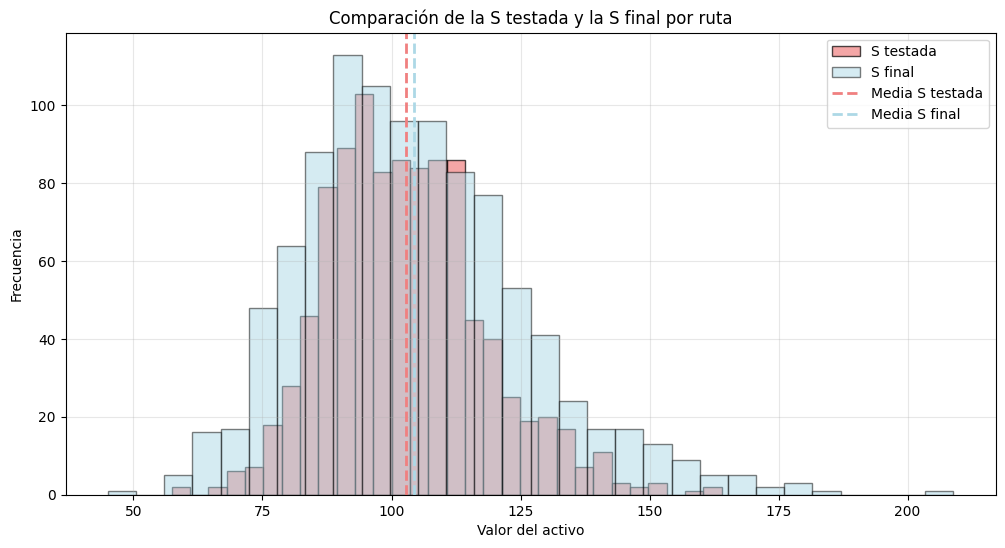

In [14]:
# S testada ponderada por cada ruta
weights = np.arange(1, num_days + 1, dtype=float)
S_testada = np.array([
    np.average(price_trajectories[1:, i], weights=weights)
    for i in range(num_trajectories)
])

# S final de cada ruta
S_final = price_trajectories[-1, :]

print(f"S_testada promedio: {S_testada.mean():.4f}")
print(f"S_testada mínimo: {S_testada.min():.4f}")
print(f"S_testada máximo: {S_testada.max():.4f}")
print(f"S_final promedio: {S_final.mean():.4f}")
print(f"S_final mínimo: {S_final.min():.4f}")
print(f"S_final máximo: {S_final.max():.4f}")

plt.figure(figsize=(12, 6))
plt.hist(S_testada, bins=30, color='lightcoral', edgecolor='black', alpha=0.7, label='S testada')
plt.hist(S_final, bins=30, color='lightblue', edgecolor='black', alpha=0.5, label='S final')

plt.axvline(S_testada.mean(), color='lightcoral', linestyle='--', linewidth=2, label='Media S testada')
plt.axvline(S_final.mean(), color='lightblue', linestyle='--', linewidth=2, label='Media S final')

plt.title('Comparación de la S testada y la S final por ruta')
plt.xlabel('Valor del activo')
plt.ylabel('Frecuencia')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## Valuación de las opciones europea y asiática

Con las trayectorias simuladas se valúan dos calls con strike $K=100$:

- **Call europeo:** paga sobre el precio final, $\text{payoff} = \max(S_{final} - K,\ 0)$
- **Call asiático:** paga sobre el promedio aritmético del precio a lo largo de la trayectoria, $\text{payoff} = \max(S_{asiática} - K,\ 0)$

Ambos payoffs se descuentan a valor presente bajo la tasa libre de riesgo:

$$V_0 = e^{-rT}\,\mathbb{E}[\text{payoff}]$$

Como el promedio de la trayectoria suaviza la volatilidad, se espera que el call asiático valga menos que el europeo, lo cual se refleja en los resultados obtenidos.

In [15]:
# Parámetros extras para payoff
K = 100

# Call europeo: payoff al vencimiento
payoff_europeo = np.maximum(S_final - K, 0)

# Call asiática con media de precios desde el día 2 hasta el final
# Se excluye el primer día, como pediste
S_asiatica = np.array([
    np.mean(price_trajectories[1:, i])
    for i in range(num_trajectories)
])
payoff_asia = np.maximum(S_asiatica - K, 0)

# Descuento a valor presente
PV_europeo = np.exp(-r * T) * payoff_europeo
PV_asia = np.exp(-r * T) * payoff_asia

print(f"Valor esperado call europeo: {PV_europeo.mean():.4f}")
print(f"Valor esperado call asiático: {PV_asia.mean():.4f}")
print(f"Payoff europeo promedio: {payoff_europeo.mean():.4f}")
print(f"Payoff asiático promedio: {payoff_asia.mean():.4f}")



Valor esperado call europeo: 10.1991
Valor esperado call asiático: 5.5266
Payoff europeo promedio: 10.7220
Payoff asiático promedio: 5.8100


## Conclusión

La opción asiática resultó considerablemente más barata que la europea: al promediar el precio en lugar de tomar solo el valor final, se reduce la varianza del payoff y, con ella, la prima que hay que pagar por el derecho de compra. Esto ilustra el efecto clásico del "averaging" en las opciones path-dependent frente a las vanilla.